In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import sys
from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))
import importlib
from src.evaluate import rollout
from src.train import train_maml_within_subject_drift
from src.evaluate import evaluate_within_subject_adaptation

# Plotting style
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "lines.markersize": 5,
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
train_subjects = list(range(1, 31))
test_subjects  = list(range(31, 41))

meta_model, base_model, meta_losses, meta_accs = train_maml_within_subject_drift(
    seed=0,
    train_subjects=train_subjects,
    meta_iters=300,
    meta_batch=4,
    inner_steps=5,
    inner_lr=0.05,
    meta_lr=1e-3,
    device=device,
)

steps_list = (0, 1, 3, 5, 10)
meta_res = evaluate_within_subject_adaptation(meta_model, test_subjects, n_tasks=50, steps_list=steps_list, inner_lr=0.05)
base_res = evaluate_within_subject_adaptation(base_model, test_subjects, n_tasks=50, steps_list=steps_list, inner_lr=0.05)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy functi

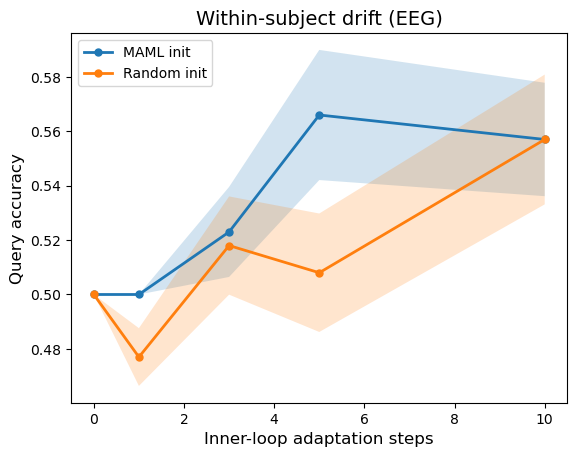

In [6]:
steps = np.array(list(steps_list), dtype=float)

meta_acc = np.array([meta_res[k]["acc_mean"] for k in steps_list])
meta_sem = np.array([meta_res[k]["acc_sem"]  for k in steps_list])

base_acc = np.array([base_res[k]["acc_mean"] for k in steps_list])
base_sem = np.array([base_res[k]["acc_sem"]  for k in steps_list])

plt.figure()
plt.plot(steps, meta_acc, marker="o", label="MAML init")
plt.fill_between(steps, meta_acc - meta_sem, meta_acc + meta_sem, alpha=0.2)

plt.plot(steps, base_acc, marker="o", label="Random init")
plt.fill_between(steps, base_acc - base_sem, base_acc + base_sem, alpha=0.2)

plt.xlabel("Inner-loop adaptation steps")
plt.ylabel("Query accuracy")
plt.title("Within-subject drift (EEG)")
plt.legend()
plt.show()
